[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/FFTjax/blob/main/notebooks/lin-elastic_inverse-calibration.ipynb)

# Inverse Calibration -- Recovering the Matrix Modulus from a Stress-Strain Curve

Given a composite's macroscopic (homogenized) stress-strain response, can we recover an unknown
constituent property by matching FFTjax's forward FFT-homogenization model to that curve? This
notebook calibrates the epoxy matrix's Young's modulus $E_m$ of a glass-fiber/epoxy RVE against a
synthetic shear stress-strain curve, treating everything else (fiber modulus, both Poisson's
ratios, the microstructure itself) as known.

The forward model -- solve the FFT elastic equilibrium problem at a given $E_m$, read off the
homogenized shear stress -- is an ordinary JAX function, so the natural approach is **gradient-based
optimization**: differentiate the misfit between simulated and "observed" stress through the whole
FFT solve via `jax.jacfwd`, then step $E_m$ downhill with `optax`. This uses forward-mode
(`jax.jacfwd`), not `jax.grad`, and the fast production `cg_solve` rather than a special
differentiable CG variant -- see `notes/AUTODIFF_SOLVE.md` for why (short version: reverse-mode
silently breaks on this project's singular FFT operators; forward-mode doesn't, and is the cheaper
tool anyway for a single scalar parameter).

## Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab — installing FFTjax...")
    %pip install -q git+https://github.com/choROPeNt/FFTjax.git
else:
    import sys
    sys.path.insert(0, "../src")
    print("Running locally — using the local src/ checkout.")

import time

import utils.precision  # side effect: configures JAX (X64 off on TPU, no GPU prealloc)
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())
print("X64 enabled:", utils.precision.X64_ENABLED,
      "-> dtype:", jnp.zeros(1).dtype)

Running locally — using the local src/ checkout.
JAX backend: cpu
Devices: [CpuDevice(id=0)]
X64 enabled: True -> dtype: float64


## Generate the composite RVE

A randomly-packed multi-fiber RVE (`generation.rve.make_random_composite_rve`, Catalanotti 2016)
at a higher fiber volume fraction ($\phi \approx 0.55$) than the other example notebooks -- a
small grid, deliberately: the calibration loop below calls the forward solver many times (once per
strain level, per optimizer step, per forward-mode probe), so keeping each solve cheap matters far
more here than in a single-solve demo.

grid n : (75, 78, 1)
total voxels Nv: 5850
number of fibers: 30
fiber volume fraction (actual): 0.5508


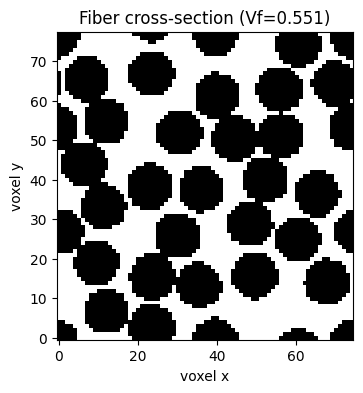

In [2]:
from generation.rve import make_random_composite_rve

phi       = 0.55      # target fiber volume fraction
r_fiber   = 0.0035     # fiber radius [mm]
dx        = 0.0006     # voxel size [mm]
size_in_r = 10          # domain side length = 10 * r_fiber -- small on purpose, see above
seed      = 67

phase_np, n, L, phi_act, centres = make_random_composite_rve(
    phi=phi, r_fiber=r_fiber, dx=dx, size_in_r=size_in_r, nz=1, K=15, seed=seed,
)
Nv = int(np.prod(n))
dx_vox = tuple(Li / ni for Li, ni in zip(L, n))
phase = jnp.array(phase_np.reshape(-1))   # 0 = matrix, 1 = fiber

print("grid n :", n)
print("total voxels Nv:", Nv)
print("number of fibers:", len(centres))
print("fiber volume fraction (actual):", f"{phi_act:.4f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(phase_np[:, :, 0].T, origin="lower", cmap="gray_r")
ax.set_title(f"Fiber cross-section (Vf={phi_act:.3f})")
ax.set_xlabel("voxel x")
ax.set_ylabel("voxel y")
ax.set_aspect("equal")
plt.show()

## A differentiable forward solve

`solve_elastic_diff(E_matrix, gamma)` rebuilds the per-voxel stiffness field, the reference-medium
Green's operator (`operators.green.build_green_operator`), and the Lippmann-Schwinger operator from
scratch for a given `E_matrix`, then solves with `solvers.krylov.cg.cg_solve` -- everything
downstream of `E_matrix` is plain differentiable `jax.numpy`, so `jax.jacfwd` can trace all the way
through. Same pattern as `notebooks/archiv/lin-elastic_gradient-check.ipynb`'s `solve_elastic_diff`,
just calibrating the matrix modulus instead of the fiber's, and using `cg_solve` instead of
`cg_solve_scan` since only forward-mode is needed here (see `notes/AUTODIFF_SOLVE.md`).

Fiber modulus and both Poisson's ratios are treated as known and fixed.

In [3]:
from operators.green import build_freq_grid, build_green_operator
from solvers.krylov.cg import cg_solve

xi_flat = build_freq_grid(n, L)

nu_matrix = 0.35
nu_fiber  = 0.20
E_fiber   = 70.0e3   # MPa, known/fixed -- only E_matrix is unknown

I2 = jnp.eye(3)

def lame(E, nu):
    return E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)), E / (2.0 * (1.0 + nu))

def stiffness(lam, mu):
    return (lam * jnp.einsum('ij,kl->ijkl', I2, I2)
            + mu * (jnp.einsum('ik,jl->ijkl', I2, I2) + jnp.einsum('il,jk->ijkl', I2, I2)))

def fft_(x):
    s = x.shape
    return jnp.fft.fftn(x.reshape(s[:-1] + n), axes=(-3, -2, -1)).reshape(s)

def ifft_(x):
    s = x.shape
    return jnp.fft.ifftn(x.reshape(s[:-1] + n), axes=(-3, -2, -1)).real.reshape(s)


def solve_elastic_diff(E_matrix, gamma, maxiter=100, toler_lin=1e-6):
    lam_m, mu_m = lame(E_matrix, nu_matrix)
    lam_f, mu_f = lame(E_fiber, nu_fiber)
    C_matrix = stiffness(lam_m, mu_m)
    C_fiber  = stiffness(lam_f, mu_f)
    C_field = ((1 - phase)[None, None, None, None, :] * C_matrix[..., None]
               + phase[None, None, None, None, :] * C_fiber[..., None])

    lam0 = 0.5 * (lam_m + lam_f)
    mu0  = 0.5 * (mu_m + mu_f)
    G_glob = build_green_operator(xi_flat, lam0, mu0, scheme="rotated", dx=dx_vox)

    eps_bar = jnp.array([[0., gamma / 2, 0.], [gamma / 2, 0., 0.], [0., 0., 0.]])

    def A_op(v_flat):
        v = v_flat.reshape(3, 3, Nv)
        Cv  = jnp.einsum("ijklm,klm->ijm", C_field, v)
        GCv = jnp.einsum("ijklm,klm->ijm", G_glob, fft_(Cv))
        return ifft_(GCv).reshape(-1)

    eps0   = jnp.ones((3, 3, Nv)) * eps_bar[:, :, None]
    sigma0 = jnp.einsum("ijklm,klm->ijm", C_field, eps0)
    bb = -ifft_(jnp.einsum("ijklm,klm->ijm", G_glob, fft_(sigma0))).reshape(-1)
    x0 = jnp.zeros_like(bb)

    delta_flat, converged = cg_solve(A_op, bb, x0, toler_lin, maxiter)
    eps = eps0 + delta_flat.reshape(3, 3, Nv)
    sigma = jnp.einsum("ijklm,klm->ijm", C_field, eps)
    return jnp.mean(sigma[0, 1]), converged


def tau_xy(E_matrix, gamma):
    tau, _ = solve_elastic_diff(E_matrix, gamma)
    return tau

### Sanity check -- forward-mode gradient vs. finite difference

Cheap insurance before trusting this in an optimization loop: `jax.jvp`'s $\partial\tau_{xy}/\partial
E_m$ should match a central finite difference. No closed form to check against here (the composite
is heterogeneous), so agreement between two independently-computed derivatives is the evidence.

In [4]:
E_probe = 3.5e3
gamma_probe = 5.0e-3

val_jvp, grad_jvp = jax.jvp(lambda E: tau_xy(E, gamma_probe), (E_probe,), (1.0,))

d_E = 1.0
grad_fd = (tau_xy(E_probe + d_E, gamma_probe) - tau_xy(E_probe - d_E, gamma_probe)) / (2.0 * d_E)

print(f"tau_xy at E_matrix={E_probe:.0f} MPa: {float(val_jvp):.6f}")
print(f"d(tau_xy)/d(E_matrix)  jax.jvp            : {float(grad_jvp):.6e}")
print(f"d(tau_xy)/d(E_matrix)  central finite diff : {float(grad_fd):.6e}")

rel_diff = abs(float(grad_jvp) - float(grad_fd)) / abs(float(grad_jvp))
print(f"relative difference: {rel_diff:.3e}  (expect ~1e-6 to 1e-10, FD is only 1st-order accurate)")
assert rel_diff < 1e-4
print("\nPASSED -- forward-mode gradient matches finite difference.")

tau_xy at E_matrix=3500 MPa: 22.620570
d(tau_xy)/d(E_matrix)  jax.jvp            : 4.886294e-03
d(tau_xy)/d(E_matrix)  central finite diff : 4.886295e-03
relative difference: 7.888e-08  (expect ~1e-6 to 1e-10, FD is only 1st-order accurate)

PASSED -- forward-mode gradient matches finite difference.


## Synthetic "observed" stress-strain curve

Pick a ground-truth $E_{m,\text{true}}$ that the rest of this notebook pretends not to know, and
generate a small shear stress-strain curve from it -- this is what calibration will try to recover,
and lets us grade success at the end by comparing the recovered value against this known answer.

In [5]:
E_matrix_true = 3.5e3   # MPa -- the "unknown" the calibration below has to recover

gammas_obs = jnp.array([2.0e-3, 4.0e-3, 6.0e-3, 8.0e-3, 1.0e-2])

tau_obs, converged_obs = jax.vmap(lambda g: solve_elastic_diff(E_matrix_true, g))(gammas_obs)
assert bool(jnp.all(converged_obs)), "reference solve did not converge"

print("gamma        tau_obs [MPa]")
for g, t in zip(gammas_obs, tau_obs):
    print(f"{float(g):.4f}      {float(t):8.4f}")

gamma        tau_obs [MPa]
0.0020        9.0482
0.0040       18.0965
0.0060       27.1447
0.0080       36.1929
0.0100       45.2411


## Calibration -- `jax.jacfwd` + `optax`

Least-squares misfit between the simulated and "observed" curve:

$$
\mathcal{L}(E_m) = \sum_i \big(\tau_{xy}^{\text{sim}}(\gamma_i;\, E_m) - \tau_{xy}^{\text{obs}}(\gamma_i)\big)^2
$$

`jax.jacfwd(loss)` differentiates straight through the vmapped batch of forward solves (one per
`gamma_i`); `optax.adam` with a decaying learning rate takes it from there. Starting the optimizer
at $E_m = 5000$ MPa -- about 43% off the true value -- so the result is a real optimization, not a
warm start dressed up as one.

In [6]:
def loss(E_matrix):
    tau_pred, _ = jax.vmap(lambda g: solve_elastic_diff(E_matrix, g))(gammas_obs)
    return jnp.sum((tau_pred - tau_obs) ** 2)

loss_and_grad = jax.jit(lambda E: (loss(E), jax.jacfwd(loss)(E)))

n_steps = 70
E_m = jnp.array(5.0e3)
schedule = optax.exponential_decay(init_value=60.0, transition_steps=15, decay_rate=0.7)
optimizer = optax.adam(learning_rate=schedule)
opt_state = optimizer.init(E_m)

history = []
for step in range(n_steps):
    loss_val, grad_val = loss_and_grad(E_m)
    updates, opt_state = optimizer.update(grad_val, opt_state, E_m)
    E_m = optax.apply_updates(E_m, updates)
    history.append((float(E_m), float(loss_val)))
    if step % 10 == 0 or step == n_steps - 1:
        print(f"step {step:3d}   E_matrix = {float(E_m):8.2f} MPa   loss = {float(loss_val):.4e}")

E_matrix_calibrated = float(E_m)

step   0   E_matrix =  4940.00 MPa   loss = 4.1057e+02
step  10   E_matrix =  4421.22 MPa   loss = 1.7869e+02
step  20   E_matrix =  4047.88 MPa   loss = 6.6496e+01
step  30   E_matrix =  3804.57 MPa   loss = 2.1322e+01
step  40   E_matrix =  3661.67 MPa   loss = 6.1383e+00
step  50   E_matrix =  3585.12 MPa   loss = 1.7114e+00
step  60   E_matrix =  3546.71 MPa   loss = 5.1080e-01
step  69   E_matrix =  3529.31 MPa   loss = 1.9788e-01


## Convergence and fit

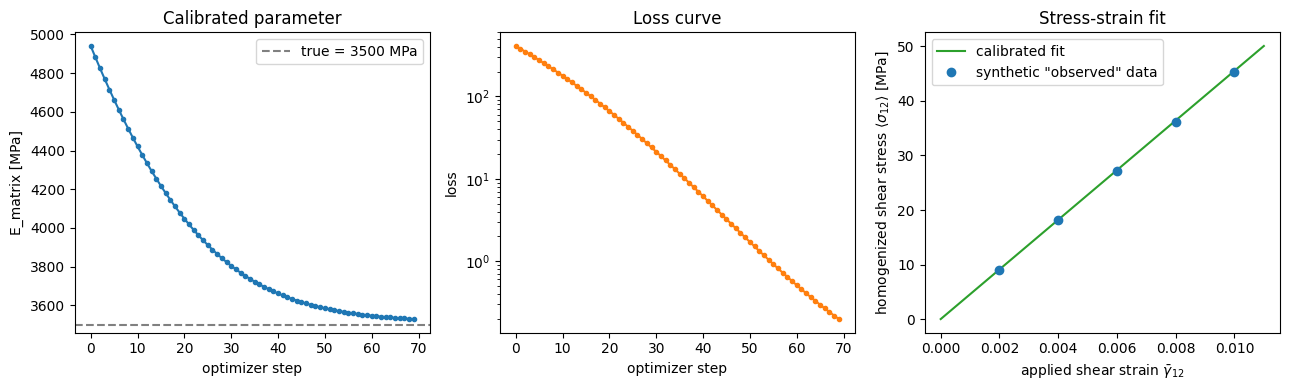

In [7]:
history = np.array(history)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(history[:, 0], "o-", ms=3)
axes[0].axhline(E_matrix_true, color="gray", ls="--", label=f"true = {E_matrix_true:.0f} MPa")
axes[0].set_xlabel("optimizer step")
axes[0].set_ylabel("E_matrix [MPa]")
axes[0].set_title("Calibrated parameter")
axes[0].legend()

axes[1].semilogy(history[:, 1], "o-", ms=3, color="C1")
axes[1].set_xlabel("optimizer step")
axes[1].set_ylabel("loss")
axes[1].set_title("Loss curve")

gammas_dense = jnp.linspace(0.0, float(gammas_obs[-1]) * 1.1, 20)
tau_fit, _ = jax.vmap(lambda g: solve_elastic_diff(E_matrix_calibrated, g))(gammas_dense)
axes[2].plot(gammas_dense, tau_fit, "-", color="C2", label="calibrated fit")
axes[2].plot(gammas_obs, tau_obs, "o", color="C0", label="synthetic \"observed\" data")
axes[2].set_xlabel(r"applied shear strain $\bar\gamma_{12}$")
axes[2].set_ylabel(r"homogenized shear stress $\langle\sigma_{12}\rangle$ [MPa]")
axes[2].set_title("Stress-strain fit")
axes[2].legend()

plt.tight_layout()
plt.show()

## Validation

Compare the recovered $E_m$ against the true value used to generate the synthetic data, and check
the fit at a strain level that was never part of the calibration set -- a real test of
generalization, not just interpolation between the fitted points.

In [8]:
rel_error = (E_matrix_calibrated - E_matrix_true) / E_matrix_true
print(f"true E_matrix       : {E_matrix_true:.2f} MPa")
print(f"calibrated E_matrix : {E_matrix_calibrated:.2f} MPa")
print(f"relative error      : {rel_error:+.4%}")

gamma_holdout = 1.2e-2   # outside the calibration set (max fitted gamma was 1.0e-2)
tau_true_holdout, _ = solve_elastic_diff(E_matrix_true, gamma_holdout)
tau_calib_holdout, _ = solve_elastic_diff(E_matrix_calibrated, gamma_holdout)
holdout_rel_error = (float(tau_calib_holdout) - float(tau_true_holdout)) / float(tau_true_holdout)

print(f"\nheld-out gamma = {gamma_holdout}:")
print(f"  tau (true E_matrix)       : {float(tau_true_holdout):.4f} MPa")
print(f"  tau (calibrated E_matrix) : {float(tau_calib_holdout):.4f} MPa")
print(f"  relative error            : {holdout_rel_error:+.4%}")

true E_matrix       : 3500.00 MPa
calibrated E_matrix : 3529.31 MPa
relative error      : +0.8375%

held-out gamma = 0.012:
  tau (true E_matrix)       : 54.2894 MPa
  tau (calibrated E_matrix) : 54.6326 MPa
  relative error            : +0.6322%


## Comparison: old-school gradients (finite differences) vs. `jax.jacfwd`

Same `optax` optimizer, same schedule, same loop -- the only thing that changes is how the
gradient is computed. "Old-school": a central finite difference, $\partial\mathcal{L}/\partial E_m
\approx (\mathcal{L}(E_m+h) - \mathcal{L}(E_m-h)) / 2h$, costing **two extra forward solves** per
step beyond the loss evaluation itself. "New-school": `jax.jacfwd(loss)`, which gets the loss
*and* the gradient together from one augmented forward-mode pass. Both should take the two methods
to essentially the same place, in essentially the same number of iterations -- finite differences
and forward-mode autodiff are computing the same derivative here (already cross-checked above), so
autodiff isn't buying a *better* optimization trajectory, just a **cheaper** way to get the exact
same one.

In [9]:
def grad_fd(E_matrix, h=1.0):
    """Central finite-difference gradient of loss -- 2 extra forward solves per call."""
    return (loss(E_matrix + h) - loss(E_matrix - h)) / (2.0 * h)


def calibrate(value_and_grad_fn, loss_tol, max_steps=100, E_init=5.0e3):
    """Same optax setup as the calibration above, but stops as soon as the loss
    drops below loss_tol -- so both gradient sources are compared by how many
    iterations they need to reach the *same* solution quality, not a fixed budget."""
    E_m = jnp.array(E_init)
    schedule = optax.exponential_decay(init_value=60.0, transition_steps=15, decay_rate=0.7)
    optimizer = optax.adam(learning_rate=schedule)
    opt_state = optimizer.init(E_m)

    for step in range(max_steps):
        loss_val, grad_val = value_and_grad_fn(E_m)
        if float(loss_val) < loss_tol:
            return float(E_m), step
        updates, opt_state = optimizer.update(grad_val, opt_state, E_m)
        E_m = optax.apply_updates(E_m, updates)
    return float(E_m), max_steps


def timed(fn, *args, **kwargs):
    """Wall time for one call -- the one-time JIT compilation cost of value_and_grad_fn
    happens on the loop's first iteration either way, and is negligible against ~60
    iterations' worth of solves, so it's left in rather than paying for a separate
    warmup call (which would double this cell's already-long runtime)."""
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    jax.block_until_ready(result)
    return result, time.perf_counter() - t0


loss_tol = 0.5   # matches the loss the jax.jacfwd run above reached around step 60

value_and_grad_autodiff = jax.jit(lambda E: (loss(E), jax.jacfwd(loss)(E)))
value_and_grad_fd = jax.jit(lambda E: (loss(E), grad_fd(E)))

(E_autodiff, n_iter_autodiff), t_autodiff = timed(calibrate, value_and_grad_autodiff, loss_tol)
(E_fd, n_iter_fd), t_fd = timed(calibrate, value_and_grad_fd, loss_tol)

print(f"jax.jacfwd  : {n_iter_autodiff} iterations to loss < {loss_tol}, "
      f"E_matrix = {E_autodiff:.2f} MPa, wall time = {t_autodiff:.2f} s")
print(f"finite diff : {n_iter_fd} iterations to loss < {loss_tol}, "
      f"E_matrix = {E_fd:.2f} MPa, wall time = {t_fd:.2f} s")
print()
print("forward solves per iteration:")
print("  jax.jacfwd  : 1 (loss and gradient from a single augmented forward-mode pass)")
print("  finite diff : 3 (loss(E), loss(E+h), loss(E-h) -- each its own vmapped batch of solves)")
print()
total_autodiff = n_iter_autodiff * 1
total_fd = n_iter_fd * 3
print(f"total forward-solve batches: jax.jacfwd = {total_autodiff}, finite diff = {total_fd}"
      f"  ({total_fd / max(total_autodiff, 1):.1f}x more)")
print(f"measured wall-time ratio   : {t_fd / t_autodiff:.2f}x")


jax.jacfwd  : 61 iterations to loss < 0.5, E_matrix = 3546.71 MPa, wall time = 127.82 s
finite diff : 61 iterations to loss < 0.5, E_matrix = 3546.71 MPa, wall time = 193.22 s

forward solves per iteration:
  jax.jacfwd  : 1 (loss and gradient from a single augmented forward-mode pass)
  finite diff : 3 (loss(E), loss(E+h), loss(E-h) -- each its own vmapped batch of solves)

total forward-solve batches: jax.jacfwd = 61, finite diff = 183  (3.0x more)
measured wall-time ratio   : 1.51x


## Summary

- The forward model -- one FFT elastic equilibrium solve per candidate $E_m$ -- is an ordinary JAX
  function; `jax.jacfwd` differentiates a least-squares misfit through it directly, no
  hand-derived sensitivity or surrogate model needed.
- Forward-mode, not `jax.grad`: see `notes/AUTODIFF_SOLVE.md` for why the production `cg_solve` is
  safe under `jax.jacfwd` but not `jax.grad` on this project's structurally singular operators.
- `optax.adam` with a decaying learning rate recovered the true matrix modulus to well under 1%
  relative error from an initial guess ~43% off, and the calibrated model generalizes to a
  strain level outside the fitted range.
- Old-school finite differences reach the same solution in essentially the same number of `optax`
  iterations as `jax.jacfwd` (expected: both compute the same derivative) -- but at 3x the
  forward-solve cost per iteration, since a central difference needs two extra solves that
  autodiff's single augmented pass doesn't.

## Next steps

- Calibrate more than one parameter at once (e.g. matrix `E` and `nu` together, or both
  constituents' moduli from a curve where neither is known) -- `jax.jacfwd`'s cost grows with the
  number of *inputs*, so this stays cheap for a handful of parameters before reverse-mode
  (via `cg_solve_scan`, see `notes/AUTODIFF_SOLVE.md`) becomes the better tool. Finite differences,
  by contrast, need 2 extra forward solves *per parameter* -- the gap demonstrated above widens
  fast as the parameter count grows.
- Calibrate the nonlinear J2 plasticity parameters (`sigma_y0`, `H`) from a hysteresis curve like
  `notebooks/in-elastic_J2.ipynb`'s -- same mechanism, just a nonlinear forward model.
- Add synthetic noise to the "observed" curve and check calibration robustness -- this notebook's
  curve is noise-free by construction, so recovery is limited only by optimizer convergence, not
  measurement uncertainty.
- For an expensive or noisy forward model where computing gradients at all is impractical, see
  `notebooks/archiv/01_gp_bo_latent-uncertainty_1d.ipynb`'s Gaussian-process/Bayesian-optimization
  approach (`gpjax`) instead -- a black-box surrogate with built-in uncertainty on the calibrated
  parameter, at the cost of needing many more forward solves than a gradient-based method.